# Daily Challenge: Binary Text Classification with IMDB Dataset

## Preprocess the Data

In [2]:
import numpy as np
from tensorflow import keras

# Load IMDB dataset keeping only the top 10,000 most frequent words
num_words = 10_000
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

# Function to one-hot encode sequences
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

# Vectorize training and test data
x_train = vectorize_sequences(x_train, dimension=num_words)
x_test = vectorize_sequences(x_test, dimension=num_words)

# Convert labels to float32
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

# Split a validation set from training data
x_val = x_train[:5000]
partial_x_train = x_train[5000:]
y_val = y_train[:5000]
partial_y_train = y_train[5000:]

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Build the Model

We’ll use a simple feedforward neural network:

- 2 hidden layers with 16 units each, ReLU activation.

- Output layer with 1 unit, sigmoid activation.

- Binary cross-entropy loss and RMSprop optimizer.

In [3]:
from tensorflow.keras import models, layers, optimizers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(num_words,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [4]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8043 - loss: 0.4990 - val_accuracy: 0.8722 - val_loss: 0.3696
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8986 - loss: 0.3025 - val_accuracy: 0.8846 - val_loss: 0.3013
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9197 - loss: 0.2325 - val_accuracy: 0.8614 - val_loss: 0.3394
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9329 - loss: 0.1932 - val_accuracy: 0.8946 - val_loss: 0.2705
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9416 - loss: 0.1672 - val_accuracy: 0.8856 - val_loss: 0.2949
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9483 - loss: 0.1484 - val_accuracy: 0.8798 - val_loss: 0.3027
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9581 - loss: 0.1275 - val_accuracy: 0.8918 - val_loss: 0.2921
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9636 - loss: 0.1140 - val_accuracy: 0.8820 - v

## Visualize Training and Validation Metrics

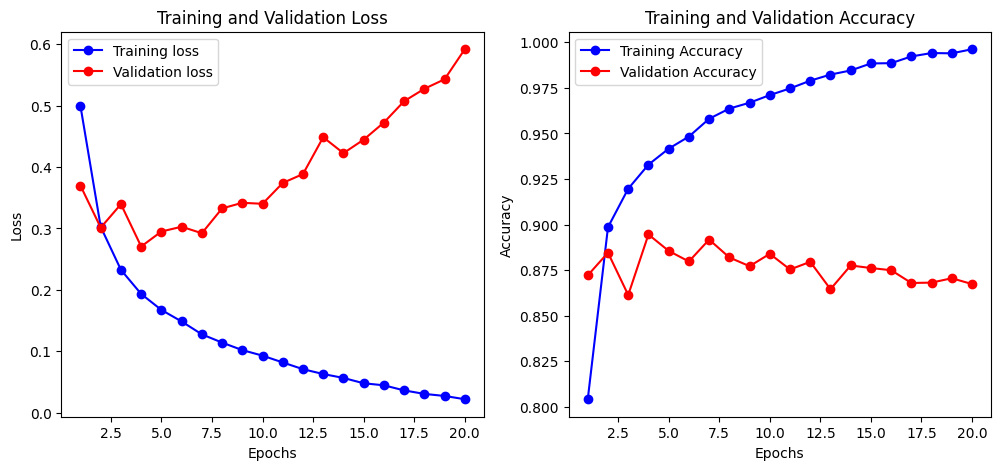

In [5]:
import matplotlib.pyplot as plt

history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

# Plot Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Retrain with Optimal Epochs

In [6]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(num_words,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train with optimal epochs
model.fit(partial_x_train, partial_y_train,
          epochs=4,
          batch_size=512,
          validation_data=(x_val, y_val))

Epoch 1/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8025 - loss: 0.4878 - val_accuracy: 0.8724 - val_loss: 0.3555
Epoch 2/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9013 - loss: 0.2911 - val_accuracy: 0.8840 - val_loss: 0.2965
Epoch 3/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9226 - loss: 0.2224 - val_accuracy: 0.8704 - val_loss: 0.3207
Epoch 4/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9355 - loss: 0.1859 - val_accuracy: 0.8854 - val_loss: 0.2848


## Evaluate on Test Set

In [7]:
results = model.evaluate(x_test, y_test)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8815 - loss: 0.2950
Test Loss: 0.2950
Test Accuracy: 0.8815
